In [17]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
df=pd.read_csv("E:\supervised learning\practical exam\WA_Fn-UseC_-Telco-Customer-Churn.csv")

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_23268\274059635.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df=pd.read_csv("E:\supervised learning\practical exam\WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
print("\nRows with whitespace in TotalCharges:")
print(df[df["TotalCharges"].str.strip() == ""])

df["TotalCharges"] = df["TotalCharges"].astype("float64")


Rows with whitespace in TotalCharges:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service    

ValueError: could not convert string to float: ' '

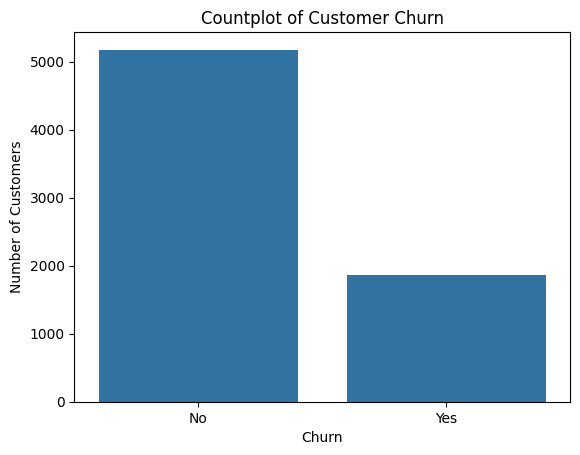

In [18]:





sns.countplot(x="Churn", data=df)

plt.title("Countplot of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")


plt.show()

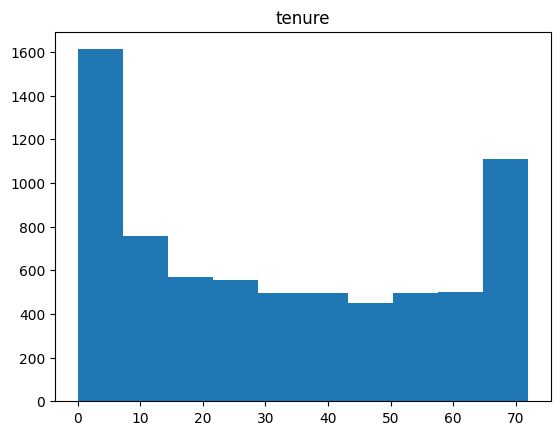

In [24]:
plt.hist(x="tenure",data= df)
plt.title("tenure")
plt.show()

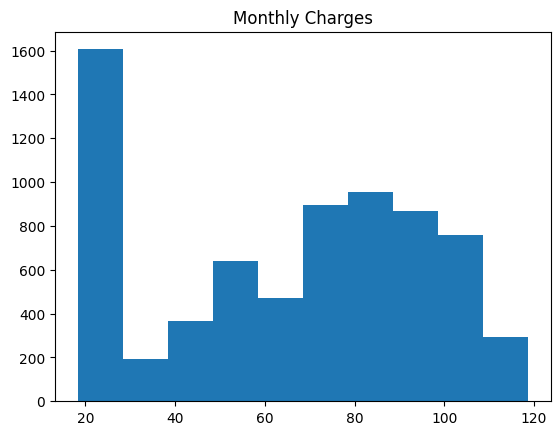

In [25]:
plt.hist("MonthlyCharges", data=df)
plt.title("Monthly Charges")
plt.show()

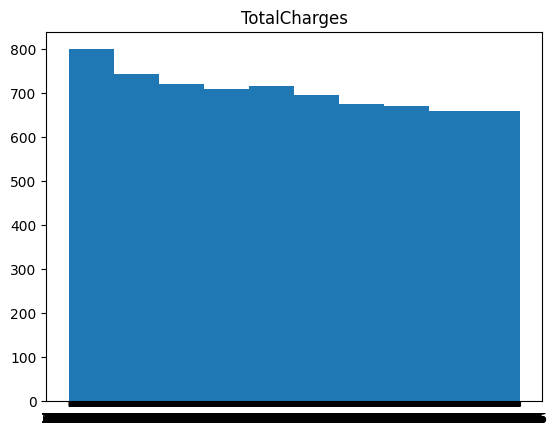

In [26]:
plt.hist("TotalCharges", data=df)
plt.title("TotalCharges")
plt.show()

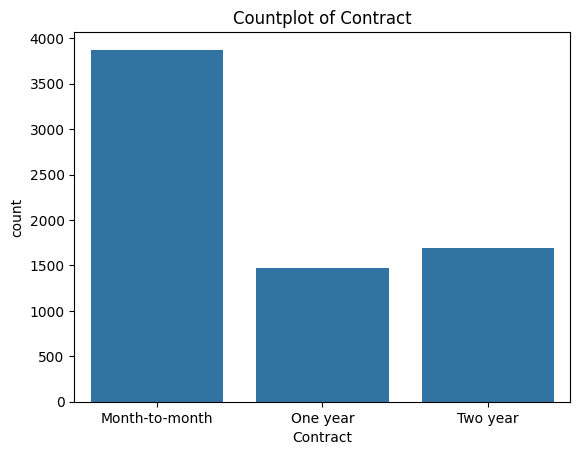

In [27]:
sns.countplot(x="Contract", data=df)

plt.title("Countplot of Contract")
plt.xlabel("Contract")
plt.show()

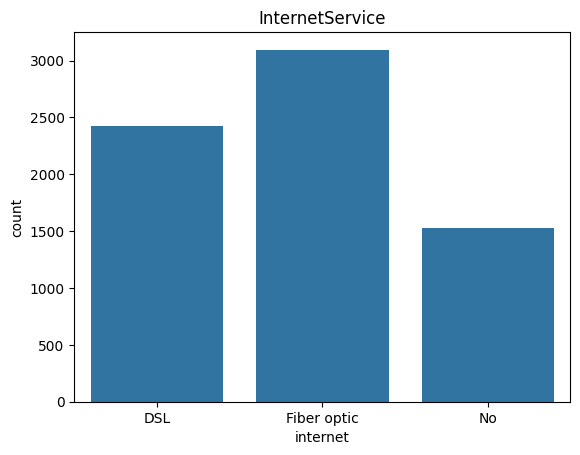

In [28]:
sns.countplot(x="InternetService", data=df)

plt.title("InternetService")
plt.xlabel("internet")
plt.show()

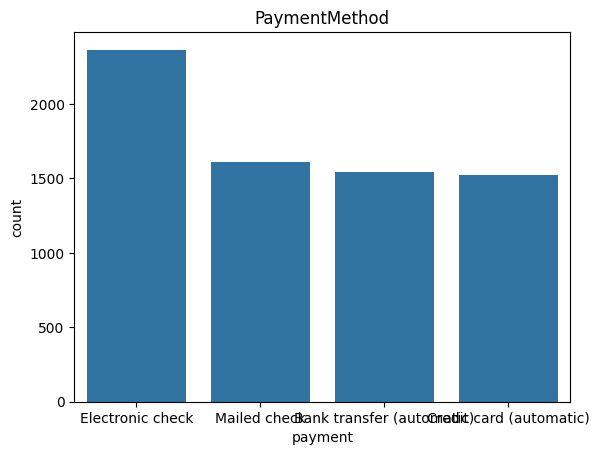

In [29]:
sns.countplot(x="PaymentMethod", data=df)

plt.title("PaymentMethod")
plt.xlabel("payment")
plt.show()


Churn Count by Contract Type:
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Contract Type with Highest Churn:
Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64


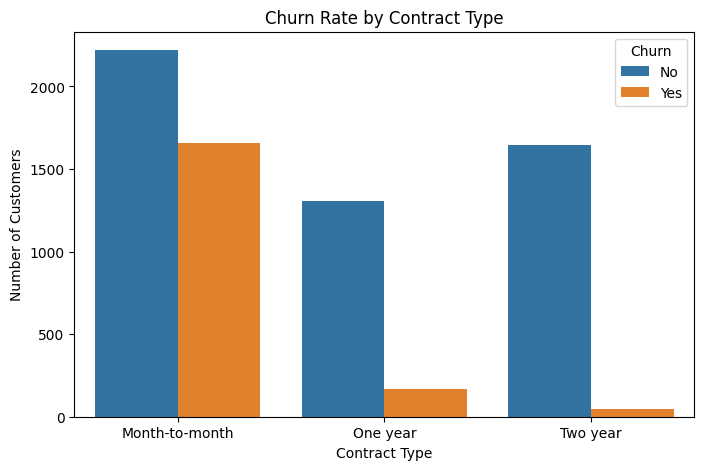

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
print("\nChurn Count by Contract Type:")
print(pd.crosstab(df["Contract"], df["Churn"]))

# Find contract type with the highest churn
churn_counts = df[df["Churn"] == "Yes"]["Contract"].value_counts()

print("\nContract Type with Highest Churn:")
print(churn_counts)

C:\Users\Admin\AppData\Local\Temp\ipykernel_23268\659994727.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby("Tenure_Bucket")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)


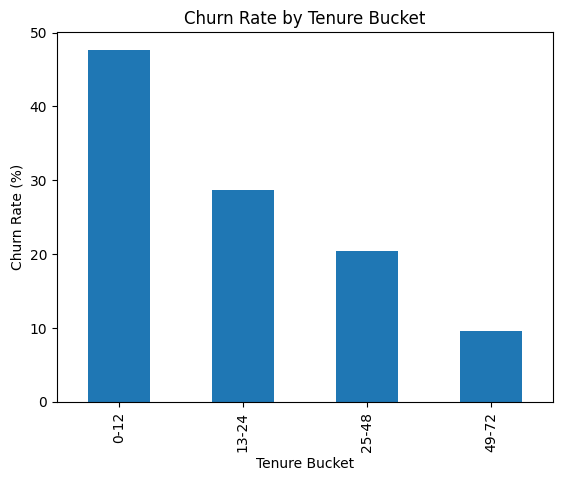

Tenure_Bucket
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64


In [31]:

# Create tenure buckets
df["Tenure_Bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

# Churn rate
churn_rate = df.groupby("Tenure_Bucket")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

# Plot
churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.ylabel("Churn Rate (%)")
plt.show()

print(churn_rate)

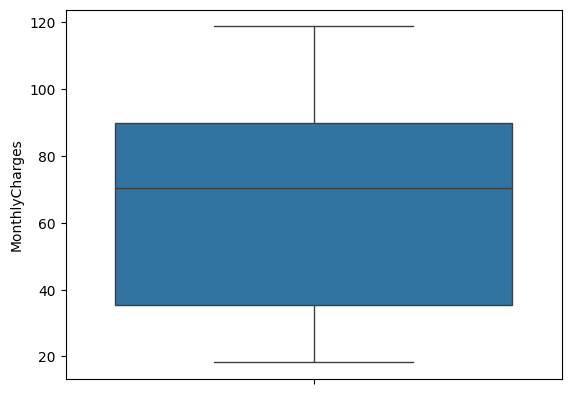

In [34]:
sns.boxplot(df["MonthlyCharges"])
plt.show()

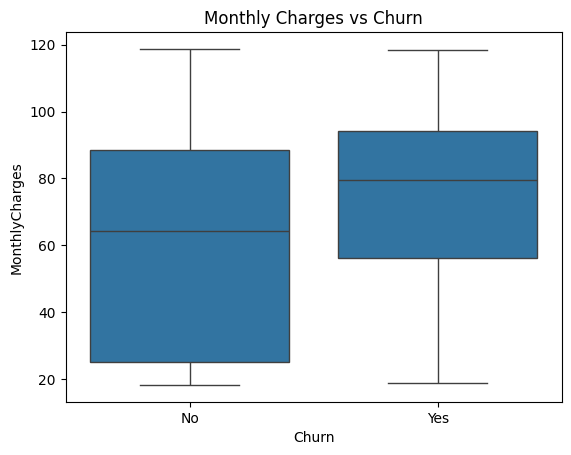

In [38]:


sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

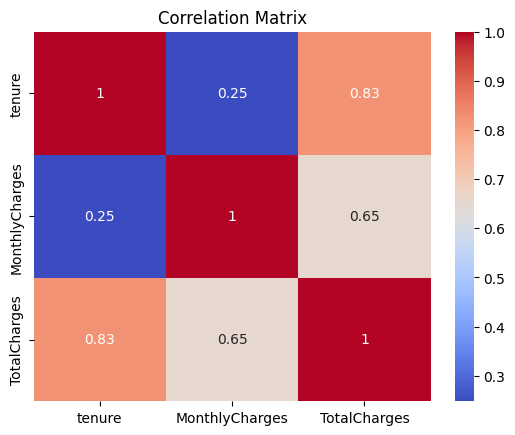

In [39]:


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

num = df[["tenure", "MonthlyCharges", "TotalCharges"]]

sns.heatmap(num.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [40]:


df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print(df.head())
print(df["TotalCharges"].isnull().sum())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1 

In [ ]:



df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 60, float("inf")],
    labels=["New", "Mid", "Senior", "Loyal"],
    include_lowest=True
)


print(df[["tenure", "tenure_group"]].head())
print(df["tenure_group"].value_counts())

   tenure tenure_group
0       1          New
1      34          Mid
2       2          New
3      45       Senior
4       2          New
tenure_group
New       2186
Mid       1856
Senior    1594
Loyal     1407
Name: count, dtype: int64
